IMDB Dataset:
   Row count: 1000, Column count: 16
   Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

TMDB Dataset:
   Row count: 4803, Column count: 20
   Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Merged data size: 458 rows, 36 columns
Common movie count: 458
Longer previous movies (>150 min): 39 movies, average rating difference: -0.2051
Shorter previous movies (≤150 min): 145 movies, average rating difference: -0.0228

p-value: 0.0106
Hypothesis is correct, longer previous movies result in lower rating on directors next movie.



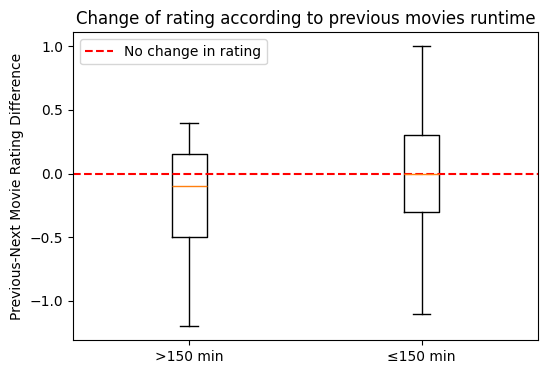

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Read files
imdb = pd.read_csv('imdb_top_1000.csv')
tmdb = pd.read_csv('tmdb_5000_movies.csv')

print("IMDB Dataset:")
print(f"   Row count: {imdb.shape[0]}, Column count: {imdb.shape[1]}")
print(f"   Columns: {imdb.columns.tolist()}\n")

print("TMDB Dataset:")
print(f"   Row count: {tmdb.shape[0]}, Column count: {tmdb.shape[1]}")
print(f"   Columns: {tmdb.columns.tolist()}\n")

#Merge the data
merged_data = pd.merge(
    imdb,
    tmdb,
    left_on='Series_Title',
    right_on='original_title',
    how='inner'
)

merged_data = merged_data.drop('original_title', axis=1)

merged_data['year'] = pd.to_numeric(merged_data['Released_Year'], errors='coerce')

#Delete movies with corrupt director and year data.
merged_data = merged_data.dropna(subset=['Director'])
merged_data = merged_data.dropna(subset=['year'])

print(f"Merged data size: {merged_data.shape[0]} rows, {merged_data.shape[1]} columns")
print(f"Common movie count: {len(merged_data)}")

#Sort movies according to directors and production years
merged_data = merged_data.sort_values(['Director', 'year'])

#Add previous movies runtime
merged_data['prev_runtime'] = merged_data.groupby('Director')['runtime'].shift(1)

#Add previous movies production year
merged_data['prev_year'] = merged_data.groupby('Director')['year'].shift(1)

#Add previous movies rating
merged_data['prev_rating'] = merged_data.groupby('Director')['IMDB_Rating'].shift(1)

#Calculate rating difference
merged_data['rating_diff'] = merged_data['IMDB_Rating'] - merged_data['prev_rating']

#Delete first movies of directors
test_data = merged_data.dropna(subset=['prev_runtime', 'rating_diff', 'prev_year'])

#Classify rating difference between previous and next movie
long_prev = test_data[test_data['prev_runtime'] > 150]['rating_diff']
short_prev = test_data[test_data['prev_runtime'] <= 150]['rating_diff']

print(f"Longer previous movies (>150 min): {len(long_prev)} movies, average rating difference: {long_prev.mean():.4f}")
print(f"Shorter previous movies (≤150 min): {len(short_prev)} movies, average rating difference: {short_prev.mean():.4f}")
print()

#T-test
from scipy import stats
t_stat, p_value = stats.ttest_ind(long_prev, short_prev)
print(f"p-value: {p_value:.4f}")

#Results of t-test
if p_value < 0.05:
    print("Hypothesis is correct, longer previous movies result in lower rating on directors next movie.\n")
else:
    print("Hypothesis is irrelevant.")

#Box plot for visualisation(I got help from AI in this part.)
plt.figure(figsize=(6,4))
plt.boxplot([long_prev, short_prev], tick_labels=['>150 min', '≤150 min'])
plt.axhline(y=0, color='r', linestyle='--', label='No change in rating')
plt.ylabel('Previous-Next Movie Rating Difference')
plt.title('Change of rating according to previous movies runtime')
plt.legend()
plt.show()